Importação de bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


Carregar e Explorar os Dados

In [6]:
# === CÉLULA 1: CARREGAMENTO ===
print("📂 Carregando dados brutos...")

df_petrolina = pd.read_csv("/content/open_meteo_history_petrolina.csv")
df_juazeiro = pd.read_csv("/content/open_meteo_history_juazeiro.csv")

# Concatenar verticalmente
df_clima = pd.concat([df_petrolina, df_juazeiro], ignore_index=True)

print(f"✅ {len(df_clima):,} registros carregados")
print(f"📅 Período: {df_clima['data'].min()} até {df_clima['data'].max()}")
print(f"🏙️ Municípios: {df_clima['municipio'].unique()}")

df_clima.head()

📂 Carregando dados brutos...
✅ 8,766 registros carregados
📅 Período: 2013-01-01 até 2024-12-31
🏙️ Municípios: ['Petrolina' 'Juazeiro']


,data,temp_media,temp_max,temp_min,precipitacao,evapotranspiracao,vento_max,municipio
0,2013-01-01,28.6,34.6,23.0,0.0,7.34,22.7,Petrolina
1,2013-01-02,29.0,34.2,24.1,0.0,7.08,20.5,Petrolina
2,2013-01-03,28.6,33.3,24.2,0.0,6.34,19.1,Petrolina
3,2013-01-04,28.5,33.7,23.7,3.7,7.19,21.6,Petrolina
4,2013-01-05,26.9,32.2,22.8,5.8,4.65,19.5,Petrolina


In [7]:
# === CÉLULA 2: ANÁLISE EXPLORATÓRIA ===
print("🔍 Análise de Qualidade dos Dados\n")

# Dimensões
print(f"📊 Shape: {df_clima.shape}")
print(f"📋 Colunas: {list(df_clima.columns)}\n")

# Missing values
missing = df_clima.isnull().sum()
missing_pct = (missing / len(df_clima) * 100).round(2)

print("❓ Valores Ausentes:")
print(pd.DataFrame({
    'Nulos': missing,
    '%': missing_pct
}).query('Nulos > 0'))

# Estatísticas descritivas
df_clima.describe()

🔍 Análise de Qualidade dos Dados

📊 Shape: (8766, 8)
📋 Colunas: ['data', 'temp_media', 'temp_max', 'temp_min', 'precipitacao', 'evapotranspiracao', 'vento_max', 'municipio']

❓ Valores Ausentes:
Empty DataFrame
Columns: [Nulos, %]
Index: []


,temp_media,temp_max,temp_min,precipitacao,evapotranspiracao,vento_max
count,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000
mean,26.803639,32.034474,21.976454,1.141273,5.979584,22.580356
std,2.131513,2.650188,1.841788,4.425287,1.615186,4.873484
min,21.200000,23.500000,16.500000,0.000000,0.960000,5.700000
25%,25.100000,30.100000,20.600000,0.000000,4.810000,19.500000
50%,26.800000,32.100000,22.100000,0.000000,5.930000,23.000000
75%,28.400000,34.200000,23.300000,0.300000,7.240000,26.000000
max,33.200000,39.000000,28.600000,128.000000,10.080000,39.000000


Limpeza e Validação

In [8]:
# === CÉLULA 3: TRATAMENTO DE NULOS ===
print("🧹 Tratando valores nulos...\n")

# Converter data para datetime
df_clima['data'] = pd.to_datetime(df_clima['data'])

# Estratégia: Interpolação linear (comum para séries climáticas)
colunas_numericas = ['temp_media', 'temp_max', 'temp_min',
                      'precipitacao', 'evapotranspiracao', 'vento_max']

for col in colunas_numericas:
    if df_clima[col].isnull().sum() > 0:
        # Interpolação linear dentro de cada município
        df_clima[col] = df_clima.groupby('municipio')[col].transform(
            lambda x: x.interpolate(method='linear', limit=7)  # Max 7 dias de gap
        )
        print(f"✅ {col}: {df_clima[col].isnull().sum()} nulos restantes")

# Se ainda houver nulos após interpolação, preencher com média do mês histórico
for col in colunas_numericas:
    if df_clima[col].isnull().sum() > 0:
        df_clima['mes'] = df_clima['data'].dt.month
        df_clima[col] = df_clima.groupby(['municipio', 'mes'])[col].transform(
            lambda x: x.fillna(x.mean())
        )

print(f"\n✅ Limpeza concluída. Nulos restantes: {df_clima.isnull().sum().sum()}")

🧹 Tratando valores nulos...


✅ Limpeza concluída. Nulos restantes: 0


In [9]:
# === CÉLULA 4: VALIDAÇÃO DE CONSISTÊNCIA FÍSICA ===
print("🔬 Validando consistência física...\n")

# 1. Temperatura mínima deve ser <= máxima
temp_invalida = df_clima[df_clima['temp_min'] > df_clima['temp_max']]
print(f"⚠️ Registros com temp_min > temp_max: {len(temp_invalida)}")

if len(temp_invalida) > 0:
    # Correção: inverter valores
    df_clima.loc[temp_invalida.index, ['temp_min', 'temp_max']] = \
        df_clima.loc[temp_invalida.index, ['temp_max', 'temp_min']].values
    print("✅ Valores invertidos corrigidos")

# 2. Precipitação não pode ser negativa
precip_negativa = df_clima[df_clima['precipitacao'] < 0]
print(f"⚠️ Registros com precipitação negativa: {len(precip_negativa)}")

if len(precip_negativa) > 0:
    df_clima.loc[precip_negativa.index, 'precipitacao'] = 0
    print("✅ Valores negativos corrigidos para 0")

# 3. Outliers extremos de temperatura (física impossível para a região)
outliers_temp = df_clima[
    (df_clima['temp_max'] > 50) |
    (df_clima['temp_min'] < 0)
]
print(f"⚠️ Outliers extremos de temperatura: {len(outliers_temp)}")

if len(outliers_temp) > 0:
    # Substituir por mediana do mês
    df_clima['mes'] = df_clima['data'].dt.month
    for idx in outliers_temp.index:
        municipio = df_clima.loc[idx, 'municipio']
        mes = df_clima.loc[idx, 'mes']

        df_clima.loc[idx, 'temp_max'] = df_clima[
            (df_clima['municipio'] == municipio) &
            (df_clima['mes'] == mes)
        ]['temp_max'].median()

        df_clima.loc[idx, 'temp_min'] = df_clima[
            (df_clima['municipio'] == municipio) &
            (df_clima['mes'] == mes)
        ]['temp_min'].median()

    print("✅ Outliers substituídos por medianas mensais")

print("\n✅ Validação concluída!")

🔬 Validando consistência física...

⚠️ Registros com temp_min > temp_max: 0
⚠️ Registros com precipitação negativa: 0
⚠️ Outliers extremos de temperatura: 0

✅ Validação concluída!


Agregação Mensal

In [10]:
# === CÉLULA 5: AGREGAÇÃO PARA MENSAL ===
print("📅 Agregando dados diários para mensais...\n")

# Adicionar colunas de tempo
df_clima['ano'] = df_clima['data'].dt.year
df_clima['mes'] = df_clima['data'].dt.month

# Definir estratégias de agregação
agg_dict = {
    'temp_media': 'mean',      # Média mensal da temperatura
    'temp_max': 'max',          # Temperatura máxima do mês
    'temp_min': 'min',          # Temperatura mínima do mês
    'precipitacao': 'sum',      # Precipitação acumulada
    'evapotranspiracao': 'sum', # ET0 acumulada
    'vento_max': 'mean'         # Vento médio
}

# Agrupar por município, ano e mês
df_mensal = df_clima.groupby(['municipio', 'ano', 'mes']).agg(agg_dict).reset_index()

# Renomear colunas para clareza
df_mensal.rename(columns={
    'temp_media': 'temp_media_mensal',
    'temp_max': 'temp_maxima_mensal',
    'temp_min': 'temp_minima_mensal',
    'precipitacao': 'precipitacao_acumulada_mm',
    'evapotranspiracao': 'eto_acumulada_mm',
    'vento_max': 'vento_medio_mensal'
}, inplace=True)

print(f"✅ Agregação concluída!")
print(f"📊 Shape mensal: {df_mensal.shape}")
print(f"📅 Período: {df_mensal['ano'].min()}-{df_mensal['ano'].max()}")
print(f"📈 Meses por município: {df_mensal.groupby('municipio').size()}")

df_mensal.head(10)

📅 Agregando dados diários para mensais...

✅ Agregação concluída!
📊 Shape mensal: (288, 9)
📅 Período: 2013-2024
📈 Meses por município: municipio
Juazeiro     144
Petrolina    144
dtype: int64


,municipio,ano,mes,temp_media_mensal,temp_maxima_mensal,temp_minima_mensal,precipitacao_acumulada_mm,eto_acumulada_mm,vento_medio_mensal
0,Juazeiro,2013,1,28.264516,36.1,22.5,65.0,191.02,18.980645
1,Juazeiro,2013,2,29.596429,36.8,22.3,0.1,230.28,23.467857
2,Juazeiro,2013,3,29.554839,38.4,22.3,18.2,218.93,20.067742
3,Juazeiro,2013,4,27.566667,36.4,21.3,32.4,162.28,22.010000
4,Juazeiro,2013,5,26.645161,35.1,21.1,6.3,164.10,22.487097
5,Juazeiro,2013,6,25.856667,32.9,19.5,1.8,157.88,23.430000
6,Juazeiro,2013,7,24.732258,32.7,18.4,5.8,163.17,24.751613
7,Juazeiro,2013,8,24.677419,35.1,16.5,1.0,177.54,25.293548
8,Juazeiro,2013,9,26.320000,36.5,18.6,0.2,207.98,24.830000
9,Juazeiro,2013,10,27.616129,37.5,20.3,0.4,230.35,25.396774


Visualização de Qualidade

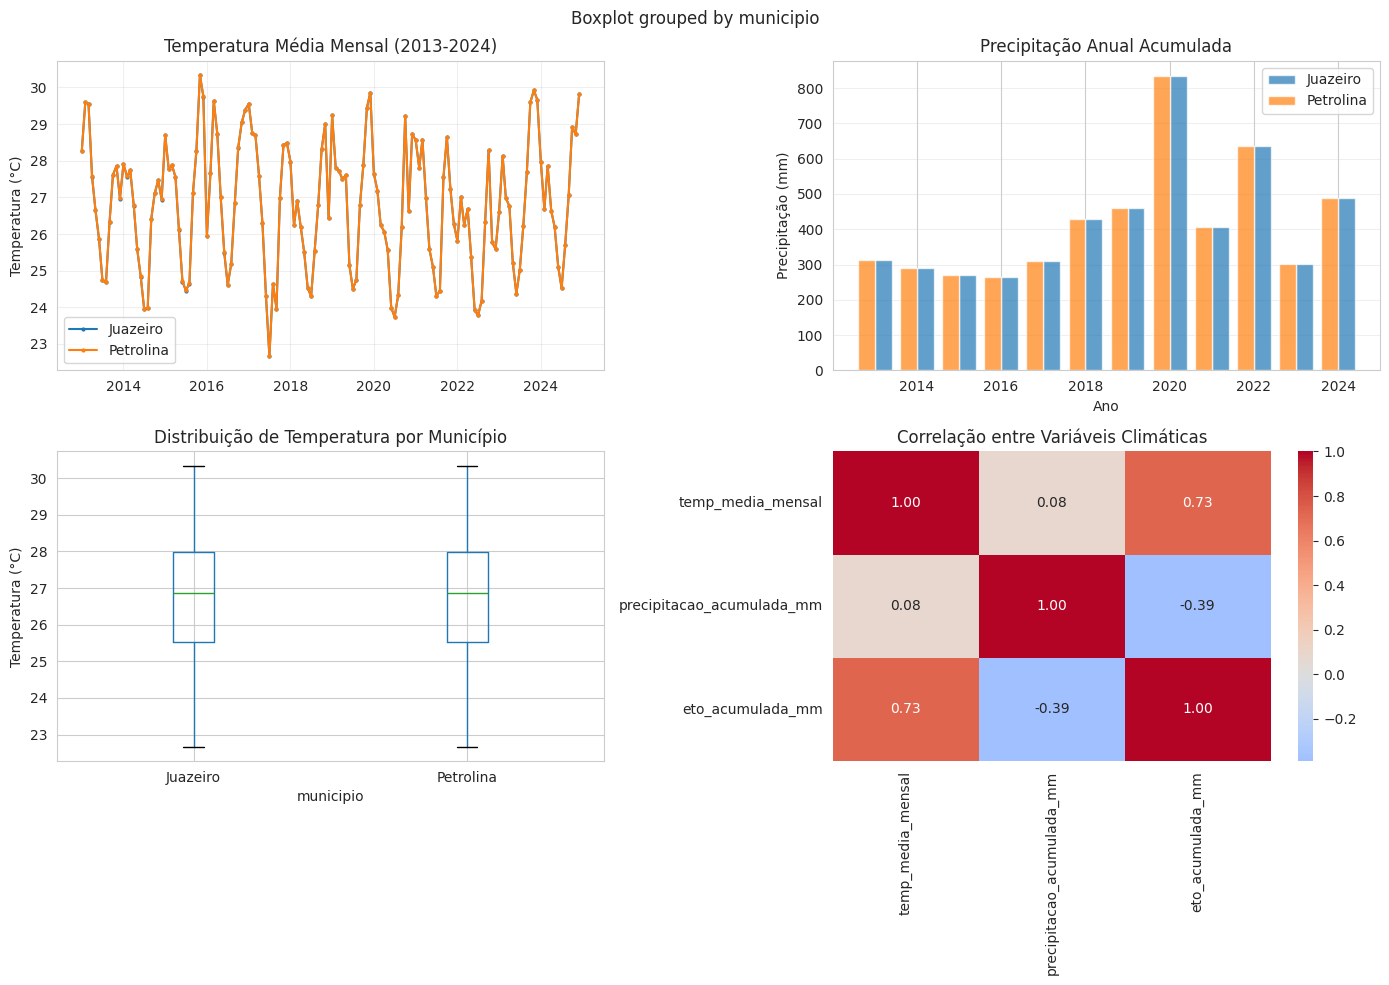

✅ Gráficos salvos em: data/processed/validacao_dados_clima.png


In [13]:
import os

# === CÉLULA 6: GRÁFICOS DE VALIDAÇÃO ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Série temporal de temperatura
for municipio in df_mensal['municipio'].unique():
    dados_mun = df_mensal[df_mensal['municipio'] == municipio].copy()
    dados_mun['data'] = pd.to_datetime(dados_mun['ano'].astype(str) + '-' + dados_mun['mes'].astype(str) + '-01')

    axes[0, 0].plot(dados_mun['data'], dados_mun['temp_media_mensal'],
                    label=municipio, marker='o', markersize=2)

axes[0, 0].set_title('Temperatura Média Mensal (2013-2024)')
axes[0, 0].set_ylabel('Temperatura (°C)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Precipitação acumulada por ano
precip_anual = df_mensal.groupby(['municipio', 'ano'])['precipitacao_acumulada_mm'].sum().reset_index()

for municipio in precip_anual['municipio'].unique():
    dados_mun = precip_anual[precip_anual['municipio'] == municipio]
    axes[0, 1].bar(dados_mun['ano'] + (0.2 if municipio == 'Juazeiro' else -0.2),
                   dados_mun['precipitacao_acumulada_mm'],
                   width=0.4, label=municipio, alpha=0.7)

axes[0, 1].set_title('Precipitação Anual Acumulada')
axes[0, 1].set_ylabel('Precipitação (mm)')
axes[0, 1].set_xlabel('Ano')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Distribuição de temperatura
df_mensal.boxplot(column='temp_media_mensal', by='municipio', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição de Temperatura por Município')
axes[1, 0].set_ylabel('Temperatura (°C)')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# 4. Correlação entre variáveis
corr_matrix = df_mensal[['temp_media_mensal', 'precipitacao_acumulada_mm',
                          'eto_acumulada_mm']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1, 1])
axes[1, 1].set_title('Correlação entre Variáveis Climáticas')

plt.tight_layout()

# Criar diretório se não existir
os.makedirs('data/processed', exist_ok=True)
plt.savefig('data/processed/validacao_dados_clima.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráficos salvos em: data/processed/validacao_dados_clima.png")

Salvar Dataset Final

In [14]:
# === CÉLULA 7: EXPORTAÇÃO ===
print("💾 Salvando dataset consolidado...\n")

# Salvar CSV mensal
output_path = "data/processed/clima_mensal_consolidado.csv"
df_mensal.to_csv(output_path, index=False)

print(f"✅ Arquivo salvo: {output_path}")
print(f"📊 Dimensões: {df_mensal.shape}")
print(f"📦 Tamanho: {df_mensal.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\n🎉 Issue #3 concluída!")

💾 Salvando dataset consolidado...

✅ Arquivo salvo: data/processed/clima_mensal_consolidado.csv
📊 Dimensões: (288, 9)
📦 Tamanho: 32.05 KB

🎉 Issue #3 concluída!
